# Supplementary Analysis

In [ ]:
# imports 
%reload_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import xarray as xr

from scipy.signal import sosfiltfilt, butter, sosfilt
os.environ['KERAS_BACKEND'] = 'torch'
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

import torch
import keras
from meegkit import dss
from scipy.signal import butter, sosfiltfilt

import mne
from mne.time_frequency import psd_array_welch
from src.EEGModalNet.models.WGAN_v0 import WGAN_GP_V0
from src.EEGModalNet.preprocessing.preprocessing import preprocess_data


# helper functions
def segment_data(x, time_dim):
    return torch.tensor(x.copy()).unfold(2, time_dim, time_dim).permute(0, 2, 3, 1).flatten(0, 1)

def reverse_segmentation(x):
    return x.unflatten(0, (10, -1)).flatten(1, 2).permute(0, 2, 1)

def generate_data(model, x, sub, pos, latent_dim=128, use_random_sub=False):
    B, T, C = x.shape
    l = len(x)
    x_mean = -4.3159e-06
    x_std = 0.4515
    x_gen = torch.zeros((B, T, C))
    bs = 128
    random_sub = keras.random.randint(sub.shape, 0, sub.max(), dtype=torch.int64)
    if use_random_sub:
        for i in range(int(l/bs)):
            x_gen[i*bs:(i+1)*bs] = model.generator((keras.random.normal((bs, latent_dim), mean=x_mean, stddev=x_std),
                                                    random_sub[i*bs:(i+1)*bs].to('mps'),
                                                    pos[:bs].to('mps'))).cpu().detach()
    else:
        for i in range(int(l/bs)):
            x_gen[i*bs:(i+1)*bs] = model.generator((keras.random.normal((bs, latent_dim), mean=x_mean, stddev=x_std),
                                                    sub[i*bs:(i+1)*bs].to('mps'),
                                                    pos[:bs].to('mps'))).cpu().detach()
    # fill in the rest
    tr_sh = (x_gen.shape[0]//bs)*bs
    if tr_sh < B:
        res = B - tr_sh
        x_gen[-res:] = model.generator((keras.random.normal((res, 128), mean=x_mean, stddev=x_std),
                                                sub[-res:].to('mps'),
                                                pos[-res:].to('mps'))).cpu().detach()

    return x_gen

def plot_psd_multi_channel(x, channels, c=0, fmin=1, fmax=49, n_fft=512, label='real', show=True, db=True, ax=None):
    _, _, C = x.shape
    if C > 1:
        x = x[:, :, [c]]
    psd, freq = mne.time_frequency.psd_array_welch(x.squeeze().flatten(0, 1).numpy(), sfreq=128, fmin=fmin, fmax=fmax, n_fft=n_fft, verbose=False)
    if db:
        psd = 10*np.log10(psd)
    if ax is not None:
        ax.plot(freq, psd, label=label)
        ax.set_title(f'Channel {channels[c]}')
    else:
        plt.plot(freq, psd, label=label)
        plt.xlim(0, fmax-1)
        plt.xlabel('Frequency (Hz)')
        plt.ylabel('Power Spectral Density (dB/Hz)')
    if show:
        plt.legend()
        plt.show()

## DATA

In [ ]:
# Data Parameters
FILTERING = True
PREPROCESSING = True
LINE_NOISE_REMOVAL = True
TIME_DIM = 512
N_SUBJECTS = 10
EEG_DATA_PATH = 'data/LEMON_data/EC_ch-8_sf-128.nc5'
CHANNELS = ['O1', 'O2', 'P1', 'P2', 'C1', 'C2', 'F1', 'F2']

# Model parameters
LATENT_DIM = 128

# PATHS
STAT_PATH = 'logs/5/20250605_7th.csv'
CHECKPOINTS_PATH = 'logs/5/20250605_7th_epoch_1280.model.keras'

# REAL DATA
xarray = xr.open_dataarray(EEG_DATA_PATH, engine='h5netcdf')

sub_id = np.random.randint(0, 202, N_SUBJECTS)
x = xarray.sel(subject=xarray.subject[sub_id], channel=CHANNELS)
x = x.to_numpy()

if PREPROCESSING:
    x = preprocess_data(x, sampling_rate=128)

if FILTERING:
    sos = butter(4, 0.5, btype='high', fs=128, output='sos')
    x = sosfiltfilt(sos, x, axis=-1)

if LINE_NOISE_REMOVAL:
    x, _ = dss.dss_line(x.T, fline=50, sfreq=128, nremove=1)
    x = x.T

x = segment_data(x, TIME_DIM)
sub = torch.tensor(np.arange(0, N_SUBJECTS).repeat(x.shape[0]//N_SUBJECTS)[:, np.newaxis])
pos = torch.tensor(xarray.ch_positions[None].repeat(x.shape[0], 0))
# data = {'x': x, 'sub': sub, 'pos': pos}

(10, 8, 61440)
>>>>Corrected Mean: 1.8454281601176598e-05, Std: 6.859095449258429e-05, Max: 0.0006003075498986249, Min: -0.000803341971809994
>>>>Scaled Mean: -0.03657953131215545, Std: 0.827990829495879, Max: 4.468760549652369, Min: -10.069740055735815
>>>>Normalized Mean: -1.3026616822268503e-16, Std: 0.9999999999999996, Max: 5.634664742330782, Min: -6.642023424017041
>>>>Clamped Mean: -1.3026616822268503e-16, Std: 0.9999999999999996, Max: 5.634664742330782, Min: -6.642023424017041
Power of components removed by DSS: 0.01


### Fake Data

In [ ]:
# FAKE DATA
model = WGAN_GP_V0(time_dim=512, feature_dim=len(CHANNELS),
                   latent_dim=LATENT_DIM, n_subjects=202,
                   use_sublayer_generator=True,
                   use_sublayer_critic=True,
                   use_channel_merger_g=False,
                   use_channel_merger_c=False,
                   interpolation='bilinear')

# load model and history
model.load_weights(CHECKPOINTS_PATH)

with torch.no_grad():
    x_gen = generate_data(model, x, sub, pos, latent_dim=LATENT_DIM)

## Metrics for features similarity

Text(0, 0.5, 'Power Spectral Density (dB/Hz)')

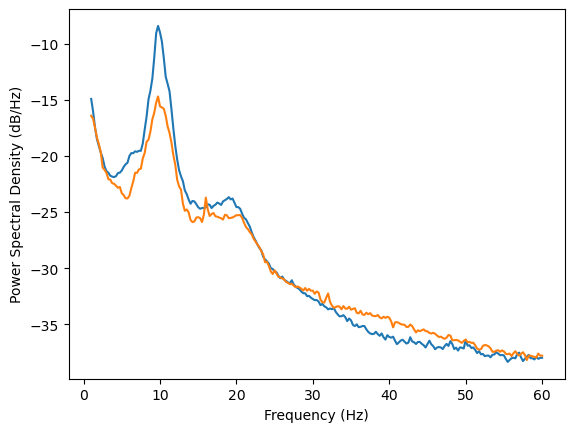

In [ ]:
# TODO: change fmin to 0.5
# TODO: change n_fft to 512
# TODO: enable using random subject in data generation
# TODO: calculate psd in two different ways
# TODO: use x mean and standard devations or not use that
psd_method = 'flat_first'

if psd_method == 'reverse_first':
    psd, freq = psd_array_welch(reverse_segmentation(x).numpy(), sfreq=128, fmin=1, fmax=60, n_fft=512, verbose=False)
    psd_gen, freq_gen = psd_array_welch(reverse_segmentation(x_gen).numpy(), sfreq=128, fmin=1, fmax=60, n_fft=512, verbose=False)
    plt.plot(freq, 10*np.log10(psd).mean(0)[0, :])
    plt.plot(freq_gen, 10*np.log10(psd_gen).mean(0)[0, :])

if psd_method == 'flat_first':
    psd, freq = psd_array_welch(x.flatten(0, 1).permute(1, 0).numpy(), sfreq=128, fmin=1, fmax=60, n_fft=512, verbose=False)
    psd_gen, freq_gen = psd_array_welch(x_gen.flatten(0, 1).permute(1, 0).numpy(), sfreq=128, fmin=1, fmax=60, n_fft=512, verbose=False)
    plt.plot(freq, 10*np.log10(psd)[0, :])
    plt.plot(freq_gen, 10*np.log10(psd_gen)[0, :])

plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density (dB/Hz)')